In [1]:
!pip install numpy pandas scikit-learn shap matplotlib seaborn

成功讀取: 2014_metrics.csv, 形狀: (30, 195)
成功讀取: 2015_metrics.csv, 形狀: (30, 193)
成功讀取: 2016_metrics.csv, 形狀: (30, 194)
成功讀取: 2017_metrics.csv, 形狀: (30, 194)
成功讀取: 2018_metrics.csv, 形狀: (30, 194)
成功讀取: 2019_metrics.csv, 形狀: (30, 194)
成功讀取: 2020_metrics.csv, 形狀: (30, 193)
成功讀取: 2021_metrics.csv, 形狀: (30, 194)
成功讀取: 2022_metrics.csv, 形狀: (30, 194)
成功讀取: 2023_metrics.csv, 形狀: (30, 194)
成功讀取: 2024_metrics.csv, 形狀: (30, 195)
成功讀取: 2025_metrics.csv, 形狀: (30, 195)
合併後數據形狀: (360, 196)
目標變量: Win Rate
初始特徵數: 194


C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Clutch WPA']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


篩選後特徵數: 149


C:\Users\petershiao\AppData\Local\Temp\ipykernel_25188\2150889179.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abs_Coefficient', y='Feature', data=coef_df.head(20), palette='viridis')
C:\Users\petershiao\AppData\Local\Temp\ipykernel_25188\2150889179.py:76: UserWarning: Glyph 32085 (\N{CJK UNIFIED IDEOGRAPH-7D55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\petershiao\AppData\Local\Temp\ipykernel_25188\2150889179.py:76: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\petershiao\AppData\Local\Temp\ipykernel_25188\2150889179.py:76: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\petershiao\AppData\Local\Temp\ipykernel_25188\2150889179.py:76: UserWarning: Glyph 2930

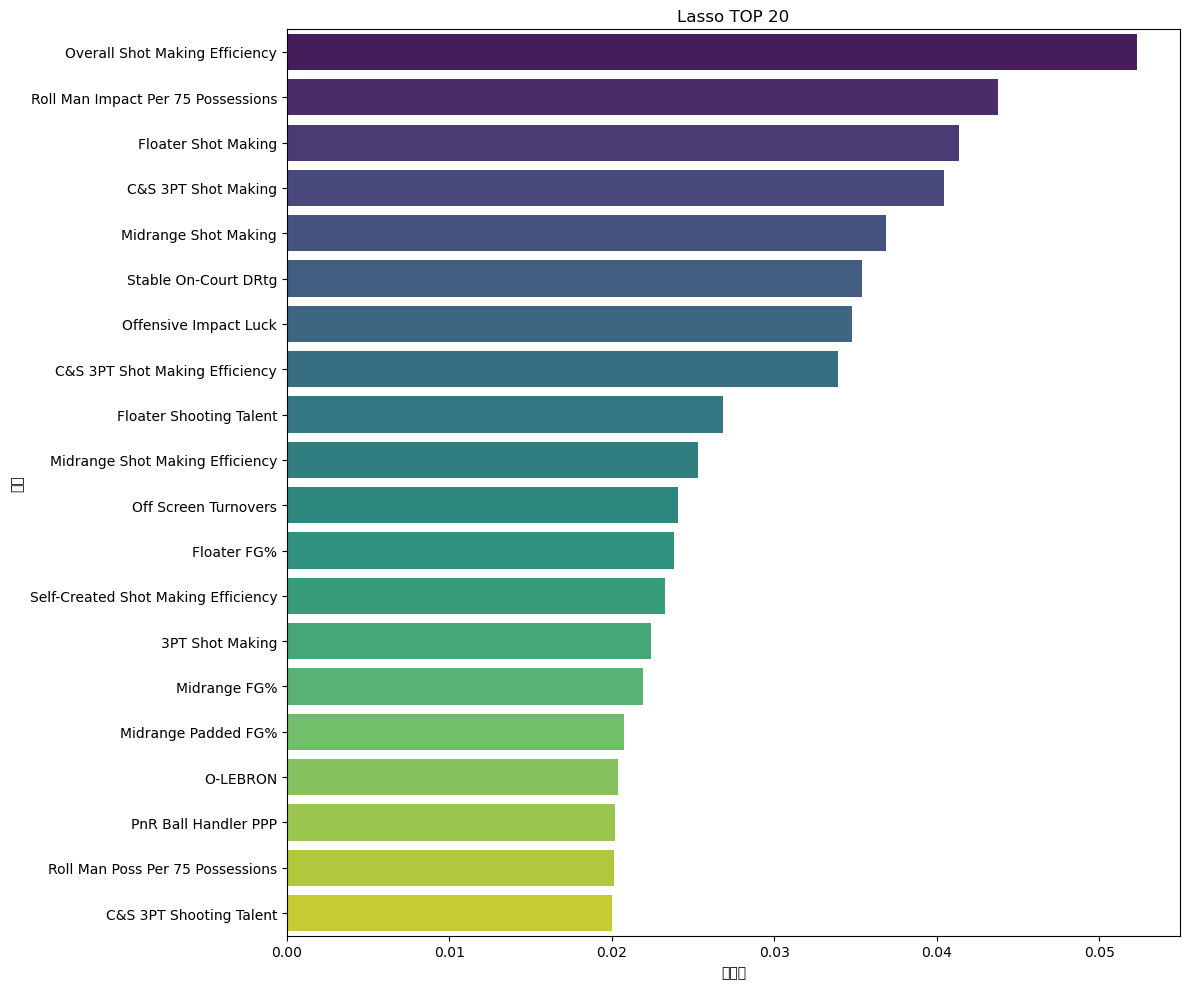

關鍵特徵：
| Feature                             |   Coefficient |   Abs_Coefficient |
|:------------------------------------|--------------:|------------------:|
| Overall Shot Making Efficiency      |    -0.0523369 |         0.0523369 |
| Roll Man Impact Per 75 Possessions  |    -0.0437814 |         0.0437814 |
| Floater Shot Making                 |     0.0413573 |         0.0413573 |
| C&S 3PT Shot Making                 |    -0.0404199 |         0.0404199 |
| Midrange Shot Making                |    -0.0368668 |         0.0368668 |
| Stable On-Court DRtg                |     0.0353804 |         0.0353804 |
| Offensive Impact Luck               |    -0.0347651 |         0.0347651 |
| C&S 3PT Shot Making Efficiency      |     0.0339361 |         0.0339361 |
| Floater Shooting Talent             |    -0.0268327 |         0.0268327 |
| Midrange Shot Making Efficiency     |     0.0253262 |         0.0253262 |
| Off Screen Turnovers                |    -0.0240695 |         0.0240695 |
| Floa

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取
file_names = [
    "2014_metrics.csv", "2015_metrics.csv", "2016_metrics.csv", "2017_metrics.csv", 
    "2018_metrics.csv", "2019_metrics.csv", "2020_metrics.csv",
    "2021_metrics.csv", "2022_metrics.csv", "2023_metrics.csv",
    "2024_metrics.csv", "2025_metrics.csv"
]

all_data = []
for file in file_names:
    try:
        df = pd.read_csv(file)
        print(f"成功讀取: {file}, 形狀: {df.shape}")
        all_data.append(df)
    except Exception as e:
        print(f"讀取失敗: {file}, 錯誤: {str(e)}")

# 合併
full_data = pd.concat(all_data, ignore_index=True)
print(f"合併後數據形狀: {full_data.shape}")

# 識別勝率
target_col = 'Win Rate' if 'Win Rate' in full_data.columns else full_data.columns[-1]
print(f"目標變量: {target_col}")

# 特徵工程
features = full_data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in features:
    features.remove(target_col)
print(f"初始特徵數: {len(features)}")

# 數據處理
imputer = SimpleImputer(strategy='mean')
X = full_data[features]
y = full_data[target_col].fillna(full_data[target_col].mean())

X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Lasso
lasso = Lasso(alpha=0.0001, max_iter=10000, random_state=42)
lasso.fit(X_scaled, y)

# 篩選非0數據
selected_features = [f for f, coef in zip(features, lasso.coef_) if coef != 0]
selected_coefs = [coef for coef in lasso.coef_ if coef != 0]
print(f"篩選後特徵數: {len(selected_features)}")

# SHAP分析
explainer = shap.Explainer(lasso, X_scaled)
shap_values = explainer(X_scaled)


# 特徵係數
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs,
    'Abs_Coefficient': np.abs(selected_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Abs_Coefficient', y='Feature', data=coef_df.head(20), palette='viridis')
plt.title("Lasso TOP 20")
plt.xlabel("絕對值")
plt.ylabel("特徵")
plt.tight_layout()
plt.savefig('lasso_coefficients.png')
plt.show()

# 關鍵特徵
print("關鍵特徵：")
print(coef_df.head(20).to_markdown(index=False))

In [11]:
print(coef_df.head(20).to_markdown(index=False))

| Feature                             |   Coefficient |   Abs_Coefficient |
|:------------------------------------|--------------:|------------------:|
| Overall Shot Making Efficiency      |    -0.0523369 |         0.0523369 |
| Roll Man Impact Per 75 Possessions  |    -0.0437814 |         0.0437814 |
| Floater Shot Making                 |     0.0413573 |         0.0413573 |
| C&S 3PT Shot Making                 |    -0.0404199 |         0.0404199 |
| Midrange Shot Making                |    -0.0368668 |         0.0368668 |
| Stable On-Court DRtg                |     0.0353804 |         0.0353804 |
| Offensive Impact Luck               |    -0.0347651 |         0.0347651 |
| C&S 3PT Shot Making Efficiency      |     0.0339361 |         0.0339361 |
| Floater Shooting Talent             |    -0.0268327 |         0.0268327 |
| Midrange Shot Making Efficiency     |     0.0253262 |         0.0253262 |
| Off Screen Turnovers                |    -0.0240695 |         0.0240695 |
| Floater FG

In [15]:
print(selected_features[:20])


['3PT Shot Making', '3PT Shooting Talent', '3PT Shot Creation', '3PT Shot Quality', 'Assisted Shooting Talent', 'Assisted Shot Making Efficiency', 'Assisted FG%', 'Assisted Padded FG%', 'C&S 3PT Shot Making', 'C&S 3PT Shooting Talent', 'C&S 3PT Shot Making Efficiency', 'C&S 3PT Shot Quality', 'C&S 3PT Padded FG%', 'Deep 3PT Shooting Talent', 'Deep 3PT Shot Creation', 'Deep 3PT Shot Making Efficiency', 'Deep 3PT Shot Quality', 'Deep 3PT FG%', 'Deep 3PT Padded FG%', 'Rim Shooting Talent']


[27 15 23 17  8]
[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22, 24, 25, 26, 28, 29]

訓練組準確率 (R²): 0.6557
測試組準確率 (R²): 0.2570


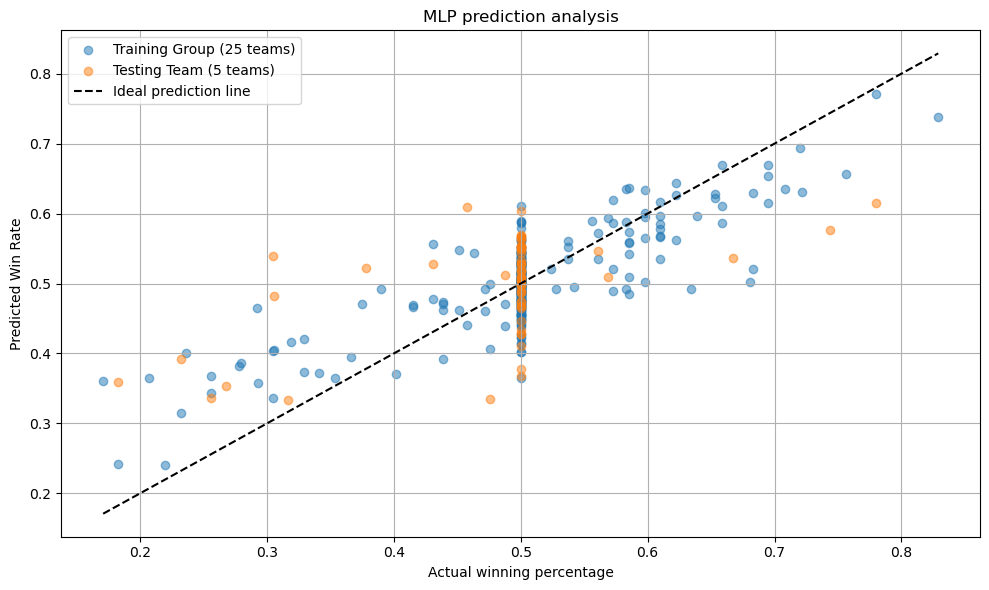


MLP模型結構:
輸入層神經元: 20
隱藏層結構: (50, 40, 30, 20)
輸出層神經元: 1


In [74]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor  # 確保正確導入
from sklearn.metrics import r2_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns

top_20_selected_features = selected_features[:20]
# 球隊分組MLP預測
# 創建模擬球隊分組 (假設每隊數據量相同)
num_teams = 30
samples_per_team = len(full_data) // num_teams
teams = np.repeat(np.arange(num_teams), samples_per_team)[:len(full_data)]
full_data['team'] = teams

# 隨機選擇5隊測試組
np.random.seed(42)
unique_teams = full_data['team'].unique()
test_teams = np.random.choice(unique_teams, size=5, replace=False)
train_teams = [team for team in unique_teams if team not in test_teams]

print(test_teams)
print(train_teams)


# 創建分組索引
train_idx = full_data['team'].isin(train_teams)
test_idx = full_data['team'].isin(test_teams)

# 提取選定特徵
selected_indices = [features.index(f) for f in top_20_selected_features]
X_selected = X_scaled[:, selected_indices]

# 分割數據
X_train = X_selected[train_idx]
y_train = y[train_idx]
X_test = X_selected[test_idx]
y_test = y[test_idx]

# MLP模型訓練
mlp = MLPRegressor(
    hidden_layer_sizes = (50, 40, 30, 20), # 五層神經網路 (50 -> 40 -> 30 -> 20)
    activation='relu',             # 使用ReLU激活函數
    solver='adam',                 # 優化算法
    learning_rate='adaptive',      # 自適應學習率
    max_iter= 300,                 # 最大迭代次數
    random_state=42                # 確保可重複性
)
mlp.fit(X_train, y_train)

# 預測與評估
train_pred = mlp.predict(X_train)
test_pred = mlp.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

# 輸出結果
print("\n" + "="*50)
print(f"訓練組準確率 (R²): {train_r2:.4f}")
print(f"測試組準確率 (R²): {test_r2:.4f}")
print("="*50)

# 可視化預測結果
plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_pred, alpha=0.5, label='Training Group (25 teams)')
plt.scatter(y_test, test_pred, alpha=0.5, label='Testing Team (5 teams)')
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Ideal prediction line')
plt.xlabel("Actual winning percentage")
plt.ylabel("Predicted Win Rate")
plt.title("MLP prediction analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mlp_prediction.png')
plt.show()

# 輸出模型結構信息
print("\nMLP模型結構:")
print(f"輸入層神經元: {mlp.n_features_in_}")
print(f"隱藏層結構: {mlp.hidden_layer_sizes}")
print(f"輸出層神經元: {mlp.n_outputs_}")



Ridge R²: 0.4556295386922067


C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00020609713000771523, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00031976537203426414, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0003944236525987854, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sk

Lasso R²: 0.4926240942289979


C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00020609713000771523, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00031976537203426414, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0003944236525987854, tolerance: 0.00016910196181449278
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\petershiao\anaconda3\Lib\site-packages\sk


📈 Ridge R² (Test): 0.4556
📉 Lasso R² (Test): 0.4926
✅ Ridge alpha: 10.0
✅ Lasso alpha: 0.004446681383531362


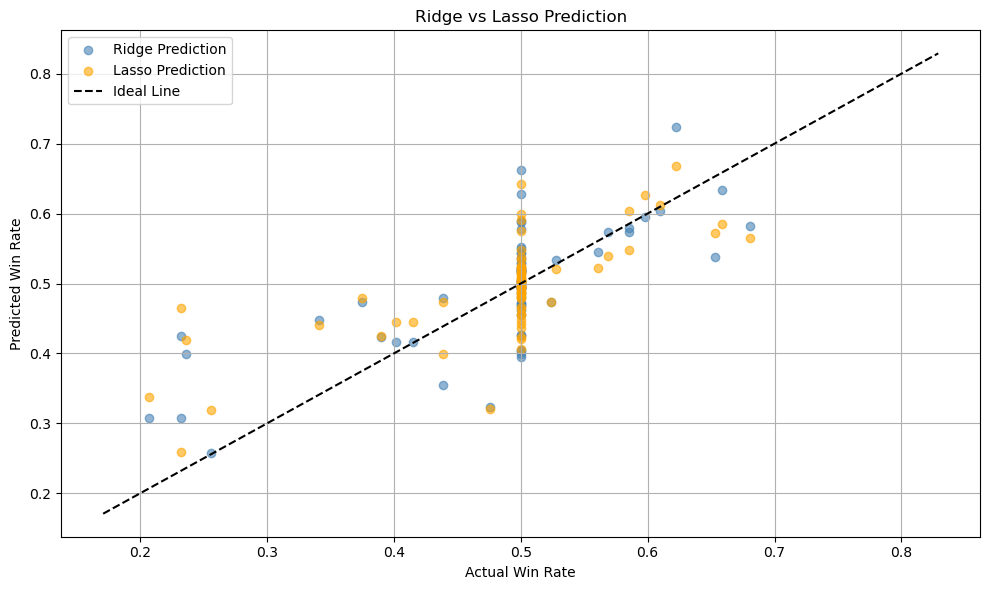

In [78]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# RidgeCV：自動幫你選 lambda（叫 alpha）
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10])
ridge.fit(X_train, y_train)
print("Ridge R²:", ridge.score(X_test, y_test))

# LassoCV：會自動把不重要的變數剃掉
lasso = LassoCV(cv=5)
lasso.fit(X_train, y_train)
print("Lasso R²:", lasso.score(X_test, y_test))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 假設 X 與 y 是你已經處理好的資料
# 如果還沒有，請先這樣做：
# X = full_data[selected_features] or X_scaled
# y = full_data[target_col]

# ➤ 1. 切分資料
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ➤ 2. 模型訓練：Ridge 與 Lasso
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10])
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# ➤ 3. 輸出評估指標
print("\n📈 Ridge R² (Test):", round(r2_score(y_test, ridge_pred), 4))
print("📉 Lasso R² (Test):", round(r2_score(y_test, lasso_pred), 4))
print("✅ Ridge alpha:", ridge.alpha_)
print("✅ Lasso alpha:", lasso.alpha_)

# ➤ 4. 圖表：預測值 vs 實際值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, ridge_pred, alpha=0.6, label='Ridge Prediction', color='steelblue')
plt.scatter(y_test, lasso_pred, alpha=0.6, label='Lasso Prediction', color='orange')
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Ideal Line')

plt.xlabel("Actual Win Rate")
plt.ylabel("Predicted Win Rate")
plt.title("Ridge vs Lasso Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ridge_lasso_comparison.png", dpi=300)
plt.show()
